## Patterns of Asthma in California

### Part 01. Research Plan

#### 1. Research Questions

Asthma is one of the most prevalent chronic diseases today, and it has a great impact on adults, adolescents, and children that negatively influences their quality of life. This research attempts to use California, the state with the most population in the United States, as an example, to analyze the situation of asthma visits to emergency departments in California to answer the following questions:

1. What is the regional distribution of the number of asthma-related visits to EDs in California, and which areas have the most asthma patients?

2. What is the regional distribution of the rate of asthma-related visits to EDs in California, and which areas have the most frequent visits of asthma patients?

3. What is the trend of asthma-related visits to EDs in California in terms of age groups, and how does it change with the change of years?

#### 2. Data Source

The research is based on three datasets provided by the California Department of Public Health (https://catalog.data.gov/dataset/asthma-emergency-department-visit-rates-2b2fe), including three CSV files:

1. Asthma ED Visit Rates in California by County (2015-2022)

2. Asthma ED Visit Rates in California by ZIP Code (2013-2022)

3. Asthma ED Visit Rates in California by Zip Code and Age Groups (2013-2022)

### Part 02: Implementation

#### 1. Data Preparation

In [1]:
# Load in the data

import pandas as pd

asthma_by_county = pd.read_csv("asthma-emergency-department-visit-rates-by-county-2015_2022.csv")
asthma_by_zip = pd.read_csv('asthmaedvisitrates-by-zipcode-2013to2022-allages-ca-cdph_with-county.csv')
asthma_by_zip_and_age = pd.read_csv('asthmaedvisitrates-by-zipcode-2013to2022-agegroups-ca-cdph_with-county.csv')

In [4]:
# have a look at the data
asthma_by_county.head(3)

,COUNTY,YEAR,STRATA,STRATA NAME,AGE GROUP,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE,COMMENT
0,California,2015,Total population,All ages,All ages,191904.0,50.0,NaN
1,Alameda,2015,Total population,All ages,All ages,9939.0,64.0,NaN
2,Alpine,2015,Total population,All ages,All ages,0.0,0.0,NaN


In [3]:
# have a look at the data
asthma_by_zip.head(3)

,Year,Zip_Code,county,Age_Group,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
0,2013,90001,Los Angeles,All Ages,441,85
1,2013,90002,Los Angeles,All Ages,425,79
2,2013,90003,Los Angeles,All Ages,594,88


In [2]:
# have a look at the data
asthma_by_zip_and_age.head(3)

,Year,Zip_Code,County,Age_Group,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
0,2013,90001,Los Angeles,Child,201,100
1,2013,90002,Los Angeles,Child,210,112
2,2013,90003,Los Angeles,Child,307,130


#### 2. Data Analysis

For visualizing the distribution of ED visits in map, the Shapefile provided by California Department of Technology (https://catalog.data.gov/dataset/ca-geographic-boundaries) is used here.

#### 2.1 Distribution of the number of asthma visits to EDs in California

##### 2.1.1 By county

The dynamic map showing the distribution of number of asthma-related ED visits by county in California is shown as follows. A slider is added to the map to allow the user to change the years to see the situation from 2015 to 2021. It can be obtained from the map that the distribution is similar between each year, and the asthma-related ED visits in Southern California is much more than that in Northern California. The number of visits happened in the Los Angeles County, which is the largest metropolitan area in California, is the most among all the counties.

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Focus on all ages and total population of counties in California
asthma_by_county = asthma_by_county[asthma_by_county['COUNTY'] != 'California'] # Remove the row for California as a whole, which is not a county
asthma_by_county = asthma_by_county[(asthma_by_county['STRATA'] == 'Total population') & 
                                    (asthma_by_county['STRATA NAME'] == 'All ages') & 
                                    (asthma_by_county['AGE GROUP'] == 'All ages')]

# Create a slider for selecting the year
year_selector = IntSlider(value=2015, min=2015, max=2021, step=1, description='Year:', continuous_update=False)

# Function to update the plot based on the selected year
def update_plot(year):
    asthma_year_by_county = asthma_by_county[(asthma_by_county['YEAR'] == year)]
    # Load the shapefile for California counties
    california_counties = gpd.read_file("ca_counties.zip")

    # Merge the asthma data with the shapefile
    california_counties = california_counties.merge(asthma_year_by_county, left_on='NAME', right_on='COUNTY', how='left')

    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    california_counties.plot(column='NUMBER OF ED VISITS', 
                            cmap='OrRd', 
                            legend=True, 
                            legend_kwds={'label': "Number of Asthma ED Visits"},
                            ax=ax)
    plt.title('Number of Asthma-related ED Visits in California by County in {}'.format(year), fontsize=15)
    plt.axis('off')
    plt.show()

# Use the interact function to link the slider with the update_plot function
interact(update_plot, year=year_selector)


interactive(children=(IntSlider(value=2015, continuous_update=False, description='Year:', max=2021, min=2015),…

<function __main__.update_plot(year)>

##### 2.1.2 By ZIP

From the analysis above, it is clear that Los Angeles (LA) county has the highest number of asthma-related ED vists of asthma among all counties in California. This section focuses on LA County, and uses the Shapefile provided by City of Los Angeles Geohub (https://geohub.lacity.org/datasets/lacounty::la-county-zip-codes/about) to create the map to show the distribution of asthma-related ED visits in LA county by ZIP area. According to the dynamic map, the central, northwestern, and northeastern part of LA county have larger number of ED visits. These areas are usually with high population density.

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider


# Filter the data for Los Angeles County
la_asthma_by_zip = asthma_by_zip[asthma_by_zip['county'] == 'Los Angeles']

# Load the shapefile for Los Angeles County ZIP codes
la_zip_shapes = gpd.read_file('LA_County_ZIP_Codes.zip')

# Create a slider for selecting the year
year_slider = IntSlider(value=2015, min=2015, max=2021, step=1, description='Year:', continuous_update=False)

# Function to update the map based on the selected year
def update_map(year):
    # Filter the data for the selected year
    la_asthma_year = la_asthma_by_zip[la_asthma_by_zip['Year'] == year]
    
    # Ensure the ZIP code columns are of the same type before merging
    la_zip_shapes['ZIPCODE'] = la_zip_shapes['ZIPCODE'].astype(int)
    la_zip_shapes_merged = la_zip_shapes.merge(la_asthma_year, left_on='ZIPCODE', right_on='Zip_Code', how='left')
    
    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    la_zip_shapes_merged.plot(column='Number_of_Asthma_ED_Visits', 
                              cmap='OrRd', 
                              legend=True, 
                              legend_kwds={'label': "Number of Asthma ED Visits"},
                              ax=ax)
    plt.title(f'Number of Asthma-related ED Visits in Los Angeles County by ZIP in ({year})', fontsize=15)
    plt.axis('off')
    plt.show()

# Use the interact function to link the slider with the update_map function
interact(update_map, year=year_slider)

interactive(children=(IntSlider(value=2015, continuous_update=False, description='Year:', max=2021, min=2015),…

<function __main__.update_map(year)>

#### 2.2 Distribution of the rate of asthma visits to EDs in California

The dynamic map showing the distribution of rate of asthma-related ED visits by county in California is shown as follows. A slider is added to the map to allow the user to change the years to see the situation from 2015 to 2021. The map shows that the changes from year to year are sometimes great, and the rate of asthma-related ED visits in Northern California is generally more than that in Southern California. The rates of visits in the counties belonging to San Francisco Bay Area are generally higher than other parts in California.

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Focus on all ages and total population of counties in California
asthma_by_county = asthma_by_county[asthma_by_county['COUNTY'] != 'California'] # Remove the row for California as a whole, which is not a county
asthma_by_county = asthma_by_county[(asthma_by_county['STRATA'] == 'Total population') & 
                                    (asthma_by_county['STRATA NAME'] == 'All ages') & 
                                    (asthma_by_county['AGE GROUP'] == 'All ages')]

# Create a slider for selecting the year
year_selector = IntSlider(value=2015, min=2015, max=2021, step=1, description='Year:', continuous_update=False)

# Function to update the plot based on the selected year
def update_plot(year):
    asthma_year_by_county = asthma_by_county[(asthma_by_county['YEAR'] == year)]
    # Load the shapefile for California counties
    california_counties = gpd.read_file("ca_counties.zip")

    # Merge the asthma data with the shapefile
    california_counties = california_counties.merge(asthma_year_by_county, left_on='NAME', right_on='COUNTY', how='left')

    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    california_counties.plot(column='AGE-ADJUSTED ED VISIT RATE', 
                            cmap='OrRd', 
                            legend=True, 
                            legend_kwds={'label': "Age-Adjusted ED Visit Rate"},
                            ax=ax)
    plt.title('Rate of Asthma-related ED Visit in California by County in {}'.format(year), fontsize=15)
    plt.axis('off')
    plt.show()

# Use the interact function to link the slider with the update_plot function
interact(update_plot, year=year_selector)

interactive(children=(IntSlider(value=2015, continuous_update=False, description='Year:', max=2021, min=2015),…

<function __main__.update_plot(year)>

#### 2.3 Asthma-related ED visits in California by Age Group

##### 2.3.1 Number

The dynamic bar charts of asthma-related ED visits in California by age group is shown as follows. According to the bar charts, both the number of asthma-related ED visits of adult patients and pediatric patients showed decreasing trends from 2013 to 2020, and the numbers in 2020 were the lowest among these years. However, the numbers increased in 2022, which means that the lowest value in 2020 may be due to the difficulty to provide in-person medical treatment due to the epidemic.

Overall, adults had a greater number of asthma-related ED visits than children in California. However, it should also be noted that the number of ED visits of pediatric asthma patients is about half of that of adults, which shows that the scale of pediatric asthma patients is very large. This is an issue worthy of research and attention from the health sector.

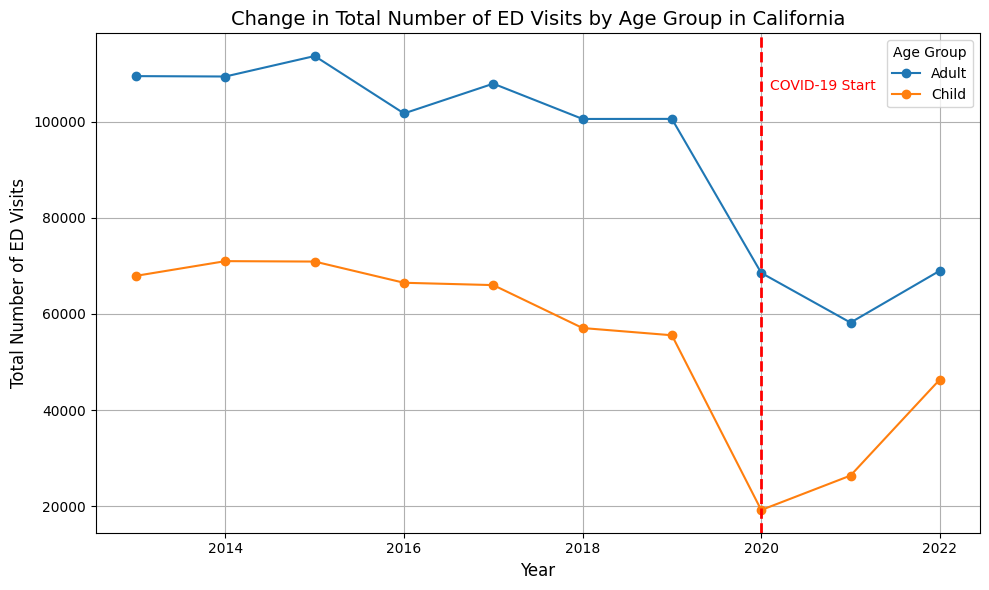

In [8]:
import matplotlib.pyplot as plt

# Group data by year and age group, summing the number of ED visits
age_group_trend = asthma_by_zip_and_age.groupby(['Year', 'Age_Group'])['Number_of_Asthma_ED_Visits'].sum().reset_index()

# Pivot the data to have age groups as columns
age_group_pivot = age_group_trend.pivot(index='Year', columns='Age_Group', values='Number_of_Asthma_ED_Visits')

# Plot the line chart
ax = age_group_pivot.plot(kind='line', figsize=(10, 6), marker='o')
plt.title('Change in Total Number of ED Visits by Age Group in California', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of ED Visits', fontsize=12)
plt.legend(title='Age Group')
plt.grid(True)

# Add a vertical line for start of COVID-19
plt.axvline(x=2020, color='red', linestyle='--', linewidth=2, label='Start of COVID-19')
plt.text(2020 + 0.1, plt.ylim()[1]*0.9, 'COVID-19 Start', color='red')  # optional: label near the line

plt.tight_layout()
plt.show()
